---
authors:
  - name: Anastasia Litinetskaya
  - name: Lukas Heumos
    roles:
      - writing – review & editing
---


(multimodal-integration-paired-integration)=
# Paired integration
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #multimodal-integration-paired-integration-key-takeaway-1
Paired integration combines modalities measured in the same cells into one representation, and no method is best for every dataset.
:::

:::{card}
:link: #multimodal-integration-paired-integration-key-takeaway-2
Integrated embeddings should be scored against the unimodal embeddings with metrics for cell type conservation and batch mixing.
:::

:::{card}
:link: #multimodal-integration-paired-integration-key-takeaway-3
WNN is a strong baseline for CITE-seq and Multiome data, and totalVI and MultiVI additionally model raw counts and batch effects.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} multimodal_integration.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(multimodal-integration-paired-integration-key-takeaway-1)=
## Motivation

Assays such as CITE-seq and 10x Multiome measure two modalities in the same cells: gene expression together with surface proteins or with chromatin accessibility.
Integrating them yields one representation per cell that combines the information of both modalities, which is called paired or vertical integration.
The modalities differ in their number of features, from about a hundred proteins to more than 100,000 peaks, and in their noise and count distributions, so each needs its own preprocessing or likelihood.

Three recent benchmarks agree that no method is best for every dataset {cite:p}`pi:hu2024benchmarking,pi:fu2025benchmarking,pi:liu2025multitask`.
Weighted nearest neighbors (WNN) ranked at or near the top for both CITE-seq and Multiome data, and totalVI ranked among the best methods for CITE-seq, especially across batches.
We integrate a CITE-seq and a Multiome dataset with these methods, compare them with MOFA+ and MultiVI, and score all embeddings against the unimodal ones.

## Dataset

We use bone marrow mononuclear cells of the NeurIPS 2021 multimodal integration challenge, which were measured with CITE-seq and with 10x Multiome at four sites {cite:p}`pi:luecken2021sandbox`.
To keep run times short, we use the three donors of the first site, whose samples still form three batches.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("jax").setLevel(logging.ERROR)

import anndata as ad
import lamindb as ln
import muon as mu
import scanpy as sc
import scvi
from scib_metrics.benchmark import Benchmarker

scvi.settings.seed = 0

ln.connect("theislab/sc-best-practices")

ln.track("m4RWUGhX2RO8")

→ connected lamindb: theislab/sc-best-practices


Seed set to 0


! It looks like you are running jupyter lab but don't have jupyter-server module installed. Please install it via pip install jupyter-server


→ loaded Transform('m4RWUGhX2RO80000', key='paired_integration.ipynb'), started new Run('4RAPew33xe4LCOAE') at 2026-09-30 12:52:59 UTC


→ notebook imports: anndata==0.13.2 lamindb-core==2.10.0 muon==0.1.9 scanpy==1.12.4 scib-metrics==0.6.1 scvi-tools==1.5.1


## CITE-seq

The CITE-seq data contain the raw counts of 13,953 genes and 134 surface proteins.

In [2]:
mdata = ln.Artifact.get(key="multimodal_integration/neurips2021_cite.h5mu").load()
mdata = mdata[mdata["rna"].obs["site"] == "site1"].copy()
mdata.pull_obs()
rna, adt = mdata["rna"], mdata["adt"]
mdata

MuData object with n_obs × n_vars = 16311 × 14087
  2 modalities
    rna:	16311 × 13953
      obs:	'cell_type', 'batch', 'site', 'donor', 'cell_type_l1'
      var:	'gene_id'
      layers:	None
    adt:	16311 × 134
      obs:	'cell_type', 'batch', 'site', 'donor', 'cell_type_l1'
      layers:	None

We normalize the gene expression with the shifted logarithm and select highly variable genes as described in the [preprocessing chapters](../preprocessing_visualization/normalization.ipynb).
Protein counts are normalized with the centered log ratio (CLR) transformation as described in the [surface protein chapter](../surface_protein/normalization.ipynb).
Both modalities keep their raw counts in a layer for the count-based models.

In [3]:
for data in (rna, adt):
    data.layers["counts"] = data.X.copy()
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=4000, batch_key="batch")
sc.pp.pca(rna, mask_var="highly_variable")
adt.X = adt.X.tocsc()
mu.prot.pp.clr(adt)
sc.pp.pca(adt, n_comps=30)
embeddings = ad.AnnData(obs=rna.obs[["cell_type", "cell_type_l1", "batch"]])
embeddings.obsm["RNA"] = rna.obsm["X_pca"]
embeddings.obsm["Protein"] = adt.obsm["X_pca"]

### Weighted nearest neighbors

WNN learns for every cell how informative each modality is, based on how well the neighbors in one modality predict its profile in the other, and combines the neighbor graphs of both modalities with these weights {cite:p}`pi:hao2021integrated`.
muon implements WNN on top of the neighbor graphs of the individual modalities {cite:p}`pi:bredikhin2022muon`.

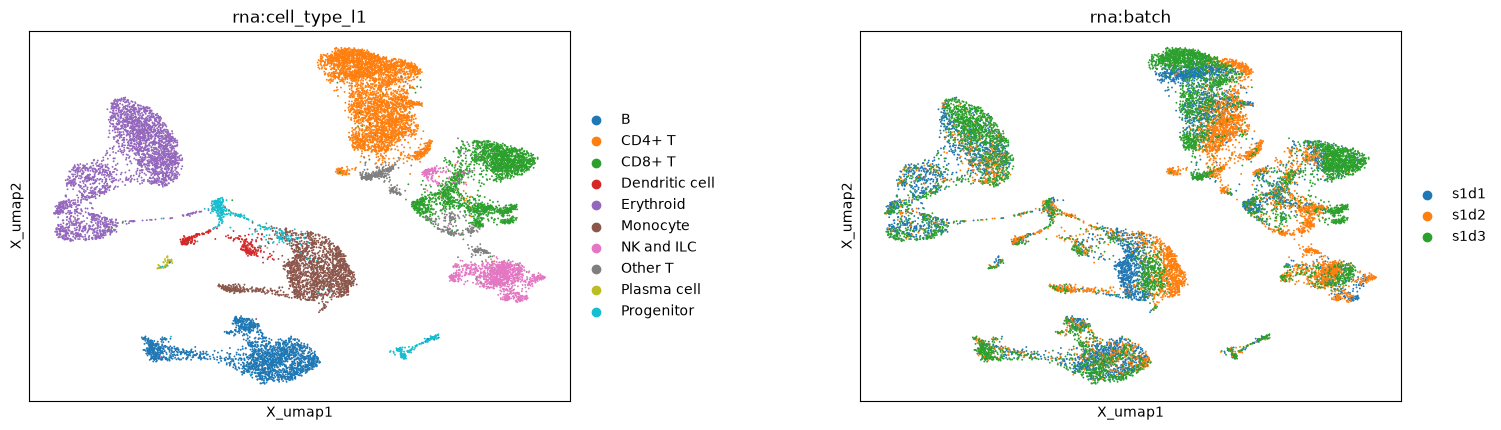

In [4]:
sc.pp.neighbors(rna)
sc.pp.neighbors(adt)
mu.pp.neighbors(mdata, key_added="wnn")
mu.tl.umap(mdata, neighbors_key="wnn")
mu.pl.umap(mdata, color=["rna:cell_type_l1", "rna:batch"], wspace=0.4)

WNN separates the lineages clearly, but cells of the same type still split by donor, since WNN combines the neighbor graphs of the uncorrected modalities.
With several batches, WNN therefore needs batch-corrected inputs for each modality.

### MOFA+

MOFA+ is a linear factor model that decomposes all modalities into a small number of factors, whose feature weights make them interpretable {cite:p}`pi:argelaguet2020mofa`.
We fit 20 factors on the highly variable genes and all proteins, and let MOFA+ model the three batches as groups.

In [5]:
adt.var["highly_variable"] = True
mdata.pull_var("highly_variable")
mu.tl.mofa(
    mdata, groups_label="rna:batch", use_var="highly_variable", n_factors=20, quiet=True
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Loaded view='rna' group='s1d1' with N=5227 samples and D=4000 features...
Loaded view='rna' group='s1d2' with N=4978 samples and D=4000 features...
Loaded view='rna' group='s1d3' with N=6106 samples and D=4000 features...
Loaded view='adt' group='s1d1' with N=5227 samples and D=134 features...
Loaded view='adt' group='s1d2' with N=4978 samples and D=134 features...
Loaded view='adt' group='s1d3' with N=6106 samples and D=134 features...




Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (rna): gaussian
- View 1 (adt): gaussian






######################################
## Training the model with seed 1 ##
######################################





Converged!



#######################
## Training finished ##
#######################


Saving model in /tmp/mofa_20260930-145339.hdf5...


Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].


### totalVI

totalVI is a variational autoencoder that models the RNA counts with a negative binomial distribution and the protein counts as a mixture of foreground and background, which accounts for the unspecific binding of antibodies {cite:p}`pi:gayoso2021joint`.
It corrects batch effects in the same model and takes the raw counts of both modalities as input.

In [6]:
rna_hvg = rna[:, rna.var["highly_variable"]].copy()
rna_hvg.obsm["protein_counts"] = adt.layers["counts"].toarray()
scvi.model.TOTALVI.setup_anndata(
    rna_hvg,
    layer="counts",
    batch_key="batch",
    protein_expression_obsm_key="protein_counts",
)
totalvi = scvi.model.TOTALVI(rna_hvg)
totalvi.train()
embeddings.obsm["totalVI"] = totalvi.get_latent_representation()

INFO     Generating sequential column names                                                                        


INFO     Computing empirical prior initialization for protein background.                                          


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


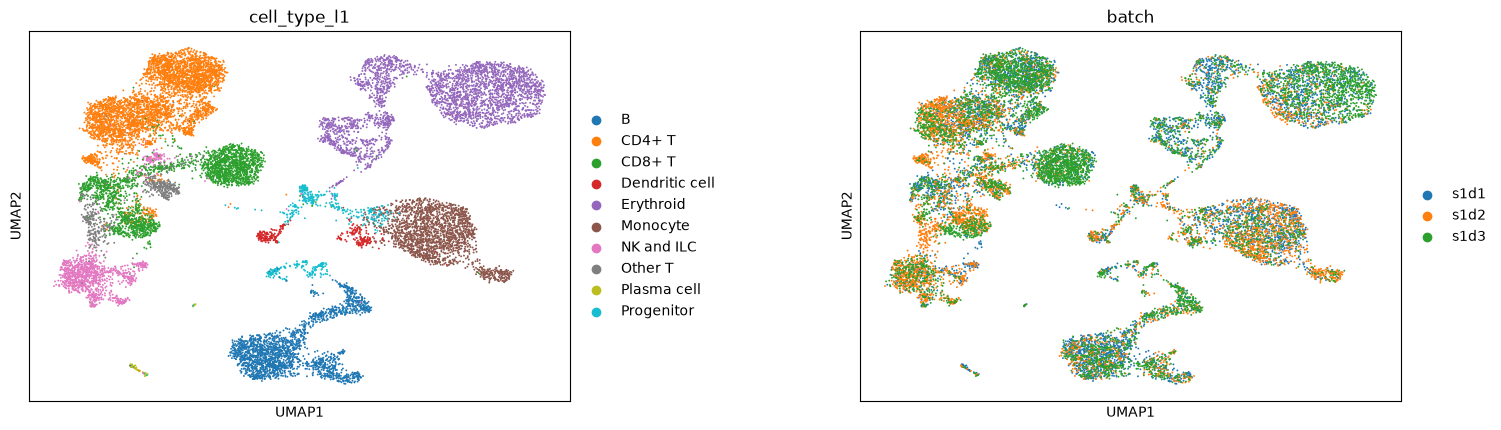

In [7]:
sc.pp.neighbors(embeddings, use_rep="totalVI")
sc.tl.umap(embeddings)
sc.pl.umap(embeddings, color=["cell_type_l1", "batch"], wspace=0.4)

totalVI mixes the three donors within each cell type, since it models the batches together with both modalities.

(multimodal-integration-paired-integration-key-takeaway-2)=
### Evaluation

We score the embeddings with the scIB metrics, which measure how well cell types are conserved and batches are mixed {cite:p}`pi:luecken2022benchmarking`.
scib-metrics replaces the silhouette-based batch metric by BRAS, since silhouette scores can reward embeddings that do not remove batch effects {cite:p}`pi:rautenstrauch2026shortcomings`.
The PCA embeddings of the individual modalities serve as baselines, and the WNN graph cannot be scored with these embedding-based metrics.

In [8]:
embeddings.obsm["MOFA+"] = mdata.obsm["X_mofa"]
benchmark = Benchmarker(
    embeddings,
    batch_key="batch",
    label_key="cell_type",
    embedding_obsm_keys=["RNA", "Protein", "MOFA+", "totalVI"],
    pre_integrated_embedding_obsm_key="RNA",
)
benchmark.benchmark()

Computing neighbors:   0%|          | 0/4 [00:00<?, ?it/s]

Computing neighbors:  25%|██▌       | 1/4 [00:05<00:15,  5.28s/it]

Computing neighbors:  50%|█████     | 2/4 [00:10<00:10,  5.10s/it]

Computing neighbors:  75%|███████▌  | 3/4 [00:15<00:05,  5.04s/it]

Computing neighbors: 100%|██████████| 4/4 [00:20<00:00,  5.04s/it]

...

Metrics:  73%|███████▎  | 8/11 [00:16<00:06,  2.28s/it, Batch correction: graph_connectivity]

Metrics:  73%|███████▎  | 8/11 [00:16<00:06,  2.28s/it, Batch correction: pcr_comparison]    

Metrics:  82%|████████▏ | 9/11 [00:16<00:03,  1.77s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 4/4 [01:34<00:00, 21.27s/it]

Embeddings: 100%|██████████| 4/4 [01:34<00:00, 23.62s/it]

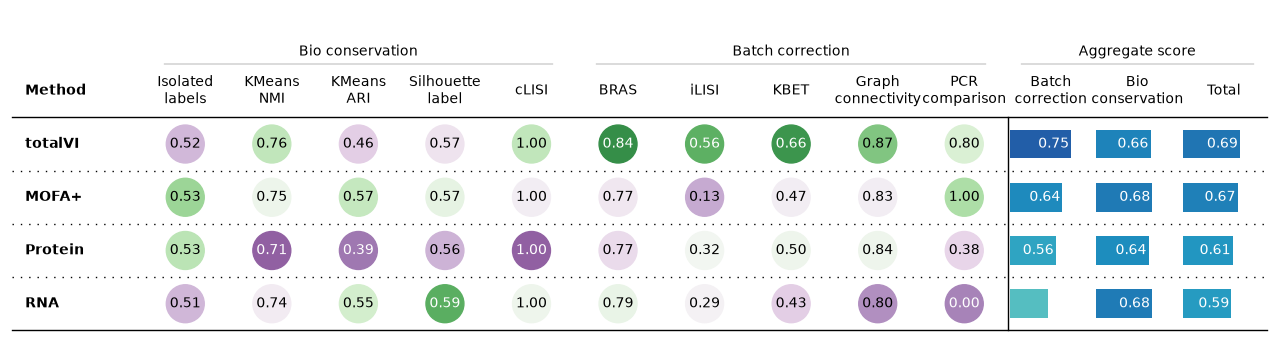

In [9]:
_ = benchmark.plot_results_table(min_max_scale=False)

totalVI achieves the best overall score, mainly because it removes the batch effects, whereas all embeddings conserve the cell types similarly well.
MOFA+ conserves cell types as well as the RNA alone, and its factors can additionally be interpreted through their gene and protein weights.

(multimodal-integration-paired-integration-key-takeaway-3)=
## Multiome

Chromatin accessibility is measured in more than 100,000 peaks and is very sparse.
We reduce it with latent semantic indexing (LSI), which applies a singular value decomposition to the TF-IDF normalized counts, and drop the first component, which mostly captures sequencing depth, as described in the [chromatin accessibility chapters](../chromatin_accessibility/introduction.ipynb).

In [10]:
mdata = ln.Artifact.get(key="multimodal_integration/neurips2021_multiome.h5mu").load()
mdata = mdata[mdata["rna"].obs["site"] == "site1"].copy()
mdata.pull_obs()
rna, atac = mdata["rna"], mdata["atac"]
for data in (rna, atac):
    data.layers["counts"] = data.X.copy()
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=4000, batch_key="batch")
sc.pp.pca(rna, mask_var="highly_variable")
mu.atac.pp.tfidf(atac, scale_factor=1e4)
mu.atac.tl.lsi(atac)
atac.obsm["X_lsi"] = atac.obsm["X_lsi"][:, 1:]
embeddings = ad.AnnData(obs=rna.obs[["cell_type", "cell_type_l1", "batch"]])
embeddings.obsm["RNA"] = rna.obsm["X_pca"]
embeddings.obsm["ATAC"] = atac.obsm["X_lsi"]

### Weighted nearest neighbors

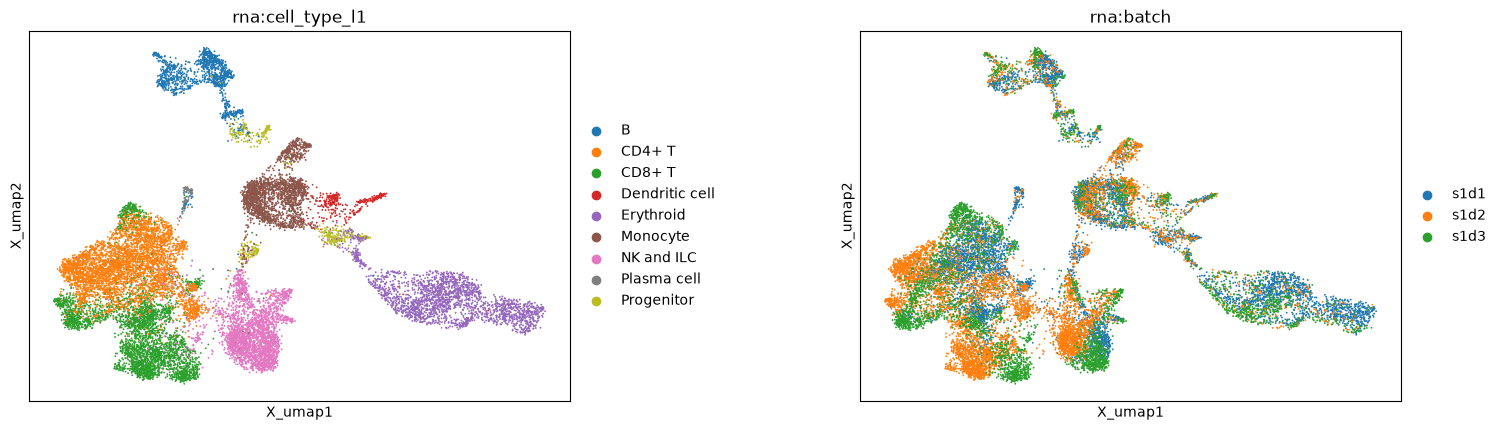

In [11]:
sc.pp.neighbors(rna)
sc.pp.neighbors(atac, use_rep="X_lsi")
mu.pp.neighbors(mdata, key_added="wnn")
mu.tl.umap(mdata, neighbors_key="wnn")
mu.pl.umap(mdata, color=["rna:cell_type_l1", "rna:batch"], wspace=0.4)

### MultiVI

MultiVI extends the variational autoencoder of scVI to chromatin accessibility and learns a joint embedding from the raw counts of both modalities {cite:p}`pi:ashuach2023multivi`.
It models whether a region is accessible rather than how many fragments it contains, although fragment counts carry additional information {cite:p}`pi:martens2024modeling`.

In [12]:
mdata_hvg = mdata[
    :, mdata["rna"].var_names[rna.var["highly_variable"]].append(atac.var_names)
].copy()
scvi.model.MULTIVI.setup_mudata(
    mdata_hvg,
    rna_layer="counts",
    atac_layer="counts",
    batch_key="batch",
    modalities={"rna_layer": "rna", "atac_layer": "atac", "batch_key": "rna"},
)
multivi = scvi.model.MULTIVI(
    mdata_hvg, n_genes=mdata_hvg["rna"].n_vars, n_regions=mdata_hvg["atac"].n_vars
)
multivi.train()
embeddings.obsm["MultiVI"] = multivi.get_latent_representation()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 12224.635. Signaling Trainer to stop.


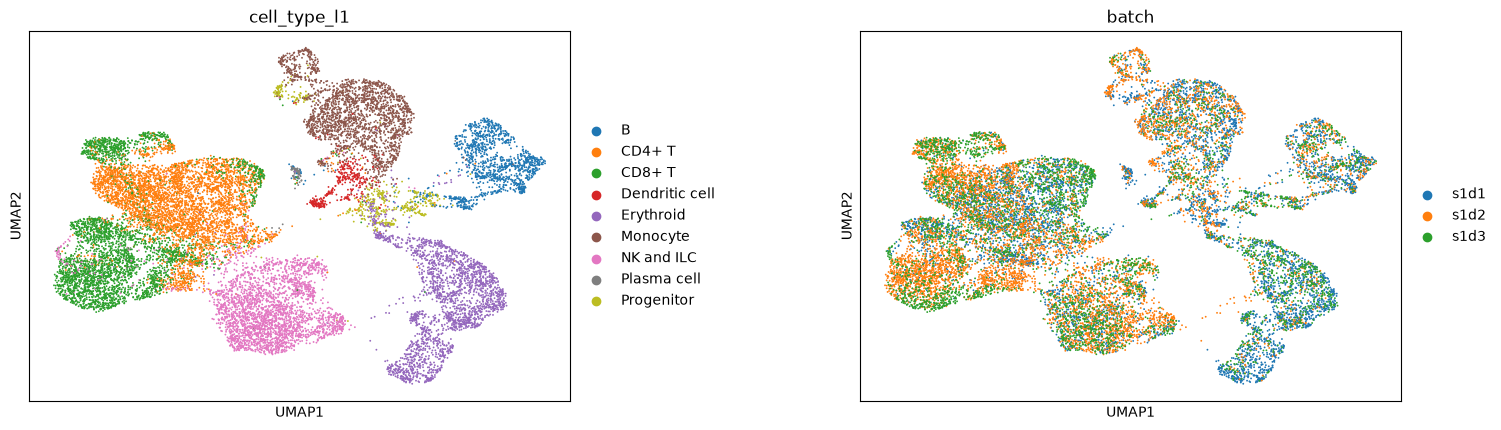

In [13]:
sc.pp.neighbors(embeddings, use_rep="MultiVI")
sc.tl.umap(embeddings)
sc.pl.umap(embeddings, color=["cell_type_l1", "batch"], wspace=0.4)

In [14]:
benchmark = Benchmarker(
    embeddings,
    batch_key="batch",
    label_key="cell_type",
    embedding_obsm_keys=["RNA", "ATAC", "MultiVI"],
    pre_integrated_embedding_obsm_key="RNA",
)
benchmark.benchmark()

Computing neighbors:   0%|          | 0/3 [00:00<?, ?it/s]

Computing neighbors:  33%|███▎      | 1/3 [00:05<00:11,  5.51s/it]

Computing neighbors:  67%|██████▋   | 2/3 [00:11<00:05,  5.51s/it]

Computing neighbors: 100%|██████████| 3/3 [00:16<00:00,  5.39s/it]

Computing neighbors: 100%|██████████| 3/3 [00:16<00:00,  5.42s/it]

...

Metrics:  73%|███████▎  | 8/11 [00:18<00:08,  2.99s/it, Batch correction: graph_connectivity]

Metrics:  73%|███████▎  | 8/11 [00:19<00:08,  2.99s/it, Batch correction: pcr_comparison]    

Metrics:  82%|████████▏ | 9/11 [00:19<00:04,  2.34s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 3/3 [01:16<00:00, 24.16s/it]

Embeddings: 100%|██████████| 3/3 [01:16<00:00, 25.36s/it]

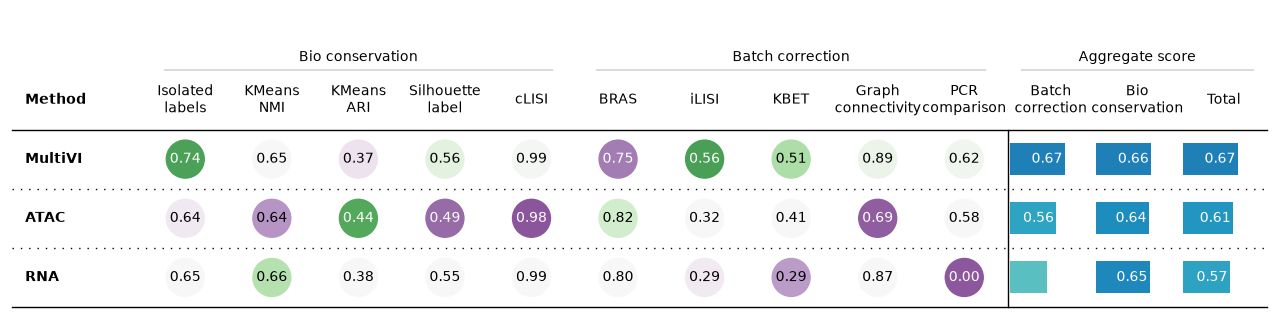

In [15]:
_ = benchmark.plot_results_table(min_max_scale=False)

MultiVI mixes the batches better than either modality alone and conserves cell types slightly better, which gives it the best overall score.
The gain from adding a second modality is modest in this dataset, whose cell types are already well separated in the RNA.

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Anastasia Litinetskaya

### Reviewers

* Lukas Heumos